# Imports

In [1]:
from fastai.vision.all import *
from sklearn.model_selection import RepeatedKFold, GroupKFold, GroupShuffleSplit, \
                                    StratifiedGroupKFold, LeaveOneGroupOut, LeavePGroupsOut
from sklearn.utils import resample
import sklearn.metrics as skm
from pathlib import Path
import numpy as np
from numpy import random
import shutil
import glob
import os
from tqdm import tqdm
import pandas as pd
from torch import cuda
import gc
import shutil
import time
state = 36
scratch = os.getenv('SLURM_SCRATCH')
print(scratch)

/scratch/slurm-624695


In [2]:
torch.cuda.current_device()

0

# Flush GPU memory if error etc.

In [7]:
try:
    del learn
except:
    print('no learner')
gc.collect()
torch.cuda.empty_cache()
!nvidia-smi

no learner
Fri Sep 15 17:14:12 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 515.65.01    Driver Version: 515.65.01    CUDA Version: 11.7     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-PCI...  On   | 00000000:3D:00.0 Off |                    0 |
| N/A   30C    P0    37W / 250W |      2MiB / 40960MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA A100-PCI...  On   | 00000000:3E:00.0 Off |                    0

# Evaluate different model performances with different learning rates etc (copy data to scratch)

In [8]:
df = pd.read_csv('/ix/rbao/Projects/panCancer_HE/data/balanced_10000_sk_lu_lv_cr_df_v1_79984tiles.tsv',
                 sep = '\t')
n = 1000 #small for debugging
df.loc[:,'tissue_anno'] = df.tissue + df.anno
df_ds = resample(df,n_samples=n,
             random_state=state, 
             replace=False,
             stratify = df.tissue_anno)
df_ds = df_ds.reset_index(drop=True)
print(df_ds.shape)
df_ds.loc[:,'scratch_fn'] = scratch + '/' + df_ds.fn.str.split('/').str[-1]
for i,fn in enumerate(tqdm(df_ds.fn.values)):
    scratch_fn = df_ds.loc[i,'scratch_fn']
    try:
        shutil.copyfile(fn,scratch_fn)
    except:
        print(scratch_fn,'Copy Failed')
print(df_ds.scratch_fn.isna().sum(),'missing')
df_ds.groupby(['tissue','anno'])['fn'].count()


(1000, 8)


100%|██████████| 1000/1000 [00:23<00:00, 42.84it/s]

0 missing


tissue      anno    
colorectal  Tumor       125
            notTumor    125
liver       Tumor       125
            notTumor    125
lung        Tumor       125
            notTumor    125
skin        Tumor       125
            notTumor    125
Name: fn, dtype: int64

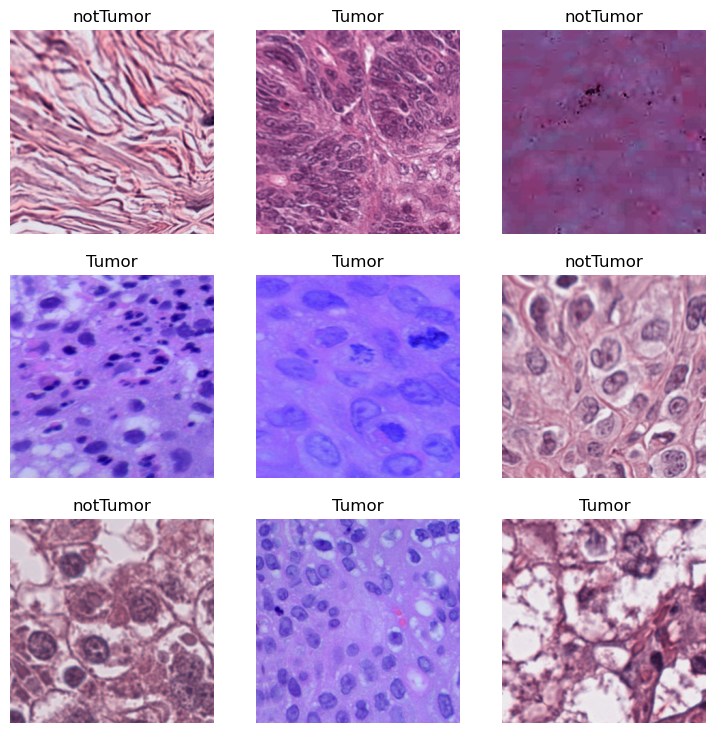

In [22]:
state = 36
splitter = TrainTestSplitter(test_size=0.1, random_state=state, stratify=df_ds.tissue_anno.values,
                    train_size=None, shuffle=True)
batch_size = 32 #250 #5000 seemed too high, resnet18->1000-2000 works, smaller for larger models
                #32 for densenet121 seems to be more predictable w/ learning rates..
                #32 works for densenet169, 128 works, 512 does not work
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_x=ColReader('scratch_fn'),
                  splitter=splitter,
                  get_y=  ColReader('anno'),
                  item_tfms=Resize(460), #Presize
                  batch_tfms=aug_transforms(size=299, #299 for inception? 224
                                            max_rotate=45, # size=224,
                                            min_scale=1,
                                            max_zoom=0,
                                            flip_vert=True,
                                           )
                             ) 
dls = tissue.dataloaders(df_ds, bs = batch_size)
dls.show_batch()

In [20]:
def my_loss(preds,target):
    a,b = preds
    return F.cross_entropy(a,target)

In [ ]:
learn = vision_learner(dls, inception_v3, loss_func = my_loss, metrics= accuracy)
learn.fit_one_cycle(10)
learn.unfreeze()
learn.fit_one_cycle(20,lr_max=3e-3)

In [15]:
learn.fine_tune(5,base_lr=1e-5)

epoch,train_loss,valid_loss,accuracy,time
0,0.297164,0.528016,0.810000,00:08


epoch,train_loss,valid_loss,accuracy,time
0,0.267430,0.529492,0.810000,00:08
1,0.286638,0.531795,0.810000,00:08
2,0.281775,0.534757,0.800000,00:08
3,0.286856,0.532280,0.800000,00:08
4,0.280356,0.531431,0.800000,00:08


densenet121, batch size of 32-> fit_one_cycle(5,0.001) -> good. then fit_one_cycle(5,lr_max=5e-4)
densenet121, batch_size = 512 -> fit_one_cycle(5,0.001) -> validation loss just keeps increasing. LR too high?

# Training from scratch?

In [24]:
df = pd.read_csv('/ix/rbao/Projects/panCancer_HE/data/balanced_10000_sk_lu_lv_cr_df_v1_79984tiles.tsv',
                 sep = '\t')
n = 4000 #small for debugging
df.loc[:,'tissue_anno'] = df.tissue + df.anno
df_ds = resample(df,n_samples=n,
             random_state=state, 
             replace=False,
             stratify = df.tissue_anno)
df_ds = df_ds.reset_index(drop=True)
print(df_ds.shape)
df_ds.loc[:,'scratch_fn'] = scratch + '/' + df_ds.fn.str.split('/').str[-1]
for i,fn in enumerate(tqdm(df_ds.fn.values)):
    scratch_fn = df_ds.loc[i,'scratch_fn']
    try:
        shutil.copyfile(fn,scratch_fn)
    except:
        print(scratch_fn,'Copy Failed')
print(df_ds.scratch_fn.isna().sum(),'missing')
df_ds.groupby(['tissue','anno'])['fn'].count()

(4000, 8)


100%|██████████| 4000/4000 [03:53<00:00, 17.13it/s]

0 missing


tissue      anno    
colorectal  Tumor       500
            notTumor    500
liver       Tumor       500
            notTumor    500
lung        Tumor       500
            notTumor    500
skin        Tumor       500
            notTumor    500
Name: fn, dtype: int64

In [48]:
batch_size = 128
state = 36
splitter = TrainTestSplitter(test_size=0.1, random_state=state, stratify=df_ds.tissue_anno.values,
                    train_size=None, shuffle=True)
tissue =DataBlock(blocks=(ImageBlock, CategoryBlock),
                  get_x=ColReader('fn'),
                  splitter=splitter,
                  get_y=  ColReader('anno'),
                  item_tfms=Resize(460), #Presize
                  batch_tfms=[*aug_transforms(size=224,
                                            max_rotate=45, # size=224,
                                            min_scale=1,
                                            max_zoom=0,
                                            flip_vert=True,
                                           ),
                              Normalize.from_stats(*imagenet_stats)]
                             ) 
dls = tissue.dataloaders(df_ds, bs = batch_size)
model = densenet169()
learn_fs = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn_fs.fit_one_cycle(20,lr_max=3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,7.022162,6.936128,0.000000,01:33
1,6.884115,6.579783,0.078049,01:37
2,6.530321,5.608796,0.687805,01:40
3,5.810321,4.007839,0.736585,01:47
4,4.787015,2.752302,0.758537,01:47
5,3.725364,1.862432,0.753659,01:49
6,2.838907,1.340045,0.770732,01:35
7,2.156608,1.006071,0.768293,01:44
8,1.652369,0.782082,0.785366,01:50
9,1.297794,0.662154,0.780488,01:41


In [78]:
print(lr_min)

SuggestedLRs(valley=0.00013182566908653826)


# Best sensitivity outcome
densenet169,batch size =128, fit_one_cycle(20),  learn.fit_one_cycle(4,lr_max=2e-3)

2030 220 18 94
sensitivity 0.8392857142857143
specificity 0.9022222222222223
false positive 0.09777777777777778
true positive 0.8392857142857143


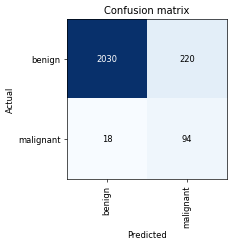

In [31]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)
sensitivity = tp/(tp + fn) #True pos / all positive
print('sensitivity',sensitivity)

specificity = tn/(fp + tn)
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/(tp + fn) )

# Test latest
densenet169, batchsize=128, fit_one_cycle(15),learn.fit_one_cycle(5,lr_max=1e-3) learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-4)
--> sensitivity 0.7321428571428571
specificity 0.9542222222222222
false positive 0.04577777777777778
true positive 0.7321428571428571

%Very good: *****
densenet 169, batchsize = 256, learn.fit_one_cycle(40), learn.fit_one_cycle(5,4e-3)
learn.unfreeze()
learn.fit_one_cycle(10,lr_max=1e-3)*****
fold 3-> sensitivity 0.8214285714285714
specificity 0.956
false positive 0.044
true positive 0.8214285714285714

fold 2->
sensitivity 0.9090909090909091
specificity 0.882201646090535
false positive 0.11779835390946503
true positive 0.9090909090909091

fold 8-> sensitivity 0.889763779527559
specificity 0.9168141592920354
false positive 0.0831858407079646
true positive 0.889763779527559

1554 141 42 339
sensitivity 0.889763779527559
specificity 0.9168141592920354
false positive 0.0831858407079646
true positive 0.889763779527559


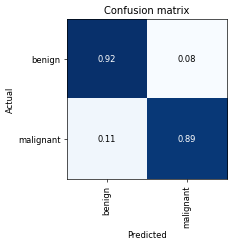

In [68]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(normalize=True,
                             figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)

all_pos = (tp + fn)
sensitivity = tp/all_pos #True positive rate
print('sensitivity',sensitivity)

specificity = tn/(fp + tn) #True negative rate
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/all_pos )

113 20 31 115
sensitivity 0.7876712328767124
specificity 0.849624060150376
false positive 0.15037593984962405
true positive 0.7876712328767124


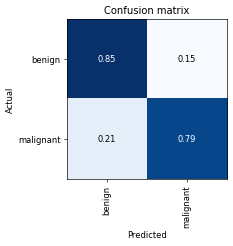

In [5]:
#Plot a confusion matrix
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(normalize=True,
                             figsize=(4,4), dpi=60)
upp, low = interp.confusion_matrix()
tn, fp = upp[0], upp[1]
fn, tp = low[0], low[1]
print(tn, fp, fn, tp)

all_pos = (tp + fn)
sensitivity = tp/all_pos #True positive rate
print('sensitivity',sensitivity)

specificity = tn/(fp + tn) #True negative rate
print('specificity',specificity) #True neg / all negative

print('false positive', fp/ (fp + tn))
print('true positive', tp/all_pos )

# Next step:
see /ix/rbao/Projects/HCC-CBS-068-Hillman-ASinghi-2/scripts/biliseq_he_class2/model_fitting/train

in particular: run_batch_slurm_fastai_cnn_fit_v2.sh